# Problem 4
(5 pts x 6): Create an optimization algorithm for solving the value of theta, phi, and lambda for the following equation:

$$U(\theta, \phi, \lambda) = H$$

Note that:
$$U(\theta, \phi, \lambda) = \begin{pmatrix}\cos{\frac{\theta}{2}} & -e^{i\lambda}\sin{\frac{\theta}{2}} \\ e^{i\phi}\sin{\frac{\theta}{2}} & e^{i(\phi+\lambda)}\cos{\frac{\theta}{2}}\end{pmatrix}$$

and

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

## Step 1: Import Required Libraries

In [2]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import HTML
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Define the U Gate and Hadamard Gate

The U gate is a universal single-qubit rotation gate parametrized by three angles:

$$U(\theta, \phi, \lambda) = \begin{pmatrix}\cos{\frac{\theta}{2}} & -e^{i\lambda}\sin{\frac{\theta}{2}} \\ e^{i\phi}\sin{\frac{\theta}{2}} & e^{i(\phi+\lambda)}\cos{\frac{\theta}{2}}\end{pmatrix}$$

In [16]:
def U_gate(theta, phi, lambda_):
    """
    Create the U gate with parameters theta, phi, and lambda.

    Parameters:
    theta (float): Rotation angle in radians
    phi (float): Phase angle in radians
    lambda_ (float): Phase angle in radians

    Returns:
    numpy.ndarray: 2x2 complex matrix
    """
    return np.array([
        [np.cos(theta/2), -np.exp(1j * lambda_) * np.sin(theta/2)],
        [np.exp(1j * phi) * np.sin(theta/2), np.exp(1j * (phi + lambda_)) * np.cos(theta/2)]
    ])

def Hadamard_gate():
    """
    Create the Hadamard gate.

    Returns:
    numpy.ndarray: 2x2 complex matrix
    """
    return (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

# Test the function
test_U = U_gate(np.pi/4, 0, 0)
print(f"U(π/4, 0, 0) = \n{test_U}")
print("\nU gate function defined!")

U(π/4, 0, 0) = 
[[ 0.92387953+0.j -0.38268343-0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

U gate function defined!


## Step 3: Create the Target Matrix H

The Hadamard gate is our target matrix:

In [4]:
# Generate the target Hadamard matrix
H = Hadamard_gate()

print(f"Target Hadamard Matrix H:")
print(H)
print(f"\nH is unitary: {np.allclose(H @ H.conj().T, np.eye(2))}")
print("\nTarget matrix created!")

Target Hadamard Matrix H:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]

H is unitary: True

Target matrix created!


## Step 4: Method 1 - Analytical Solution (Direct)

We can solve this analytically by comparing matrix elements:

From element (0,0): $\cos(\theta/2) = 1/\sqrt{2}$ → $\theta = \pi/2$

From element (0,1): $-e^{i\lambda}\sin(\theta/2) = 1/\sqrt{2}$

With $\theta = \pi/2$: $-e^{i\lambda} \cdot 1/\sqrt{2} = 1/\sqrt{2}$ → $e^{i\lambda} = -1$ → $\lambda = \pi$

From element (1,0): $e^{i\phi}\sin(\theta/2) = 1/\sqrt{2}$

With $\theta = \pi/2$: $e^{i\phi} \cdot 1/\sqrt{2} = 1/\sqrt{2}$ → $e^{i\phi} = 1$ → $\phi = 0$

In [15]:
def solve_analytical():
    """
    Solve for theta, phi, lambda using analytical method
    """
    theta = np.pi / 2
    phi = 0
    lambda_ = np.pi
    return theta, phi, lambda_

# Solve using analytical method
theta_analytical, phi_analytical, lambda_analytical = solve_analytical()

# Verify the solution
U_analytical = U_gate(theta_analytical, phi_analytical, lambda_analytical)
error_analytical = np.max(np.abs(U_analytical - H))

print("=" * 60)
print("METHOD 1: ANALYTICAL SOLUTION")
print("=" * 60)
print(f"θ (theta)  = {theta_analytical:.6f} rad = {np.degrees(theta_analytical):.4f}°")
print(f"φ (phi)    = {phi_analytical:.6f} rad = {np.degrees(phi_analytical):.4f}°")
print(f"λ (lambda) = {lambda_analytical:.6f} rad = {np.degrees(lambda_analytical):.4f}°")
print(f"\nMax error: {error_analytical:.10e}")
print("\nAnalytical solution computed!")

METHOD 1: ANALYTICAL SOLUTION
θ (theta)  = 1.570796 rad = 90.0000°
φ (phi)    = 0.000000 rad = 0.0000°
λ (lambda) = 3.141593 rad = 180.0000°

Max error: 1.4080039260e-16

Analytical solution computed!


## Step 5: Method 2 - BFGS Optimization

Use scipy's BFGS algorithm to minimize the Frobenius norm between U and H.

In [7]:
def cost_function(params):
    """
    Compute Frobenius norm squared error between U and H
    """
    theta, phi, lambda_ = params
    U = U_gate(theta, phi, lambda_)
    diff = U - H
    return np.sum(np.abs(diff)**2)

def solve_bfgs(initial_guess):
    """
    Solve for theta, phi, lambda using BFGS optimization
    """
    result = minimize(cost_function, initial_guess, method='BFGS')
    return result.x, result.fun, result.nit

# Solve using BFGS with random initial guess
np.random.seed(42)
initial_guess = np.random.uniform(-np.pi, np.pi, 3)
(theta_bfgs, phi_bfgs, lambda_bfgs), cost_bfgs, nit_bfgs = solve_bfgs(initial_guess)

# Verify the solution
U_bfgs = U_gate(theta_bfgs, phi_bfgs, lambda_bfgs)
error_bfgs = np.max(np.abs(U_bfgs - H))

print("=" * 60)
print("METHOD 2: BFGS OPTIMIZATION")
print("=" * 60)
print(f"θ (theta)  = {theta_bfgs:.6f} rad = {np.degrees(theta_bfgs):.4f}°")
print(f"φ (phi)    = {phi_bfgs:.6f} rad = {np.degrees(phi_bfgs):.4f}°")
print(f"λ (lambda) = {lambda_bfgs:.6f} rad = {np.degrees(lambda_bfgs):.4f}°")
print(f"\nMax error:   {error_bfgs:.10e}")
print(f"Iterations:  {nit_bfgs}")
print("\nBFGS optimization completed!")

METHOD 2: BFGS OPTIMIZATION
θ (theta)  = -1.570797 rad = -90.0000°
φ (phi)    = 3.141592 rad = 180.0000°
λ (lambda) = 0.000000 rad = 0.0000°

Max error:   4.1385987957e-07
Iterations:  7

BFGS optimization completed!


## Step 6: Method 3 - Nelder-Mead Optimization

Use Nelder-Mead simplex algorithm as an alternative derivative-free method.

In [18]:
def solve_nelder_mead(initial_guess):
    """
    Solve for theta, phi, lambda using Nelder-Mead optimization
    """
    result = minimize(cost_function, initial_guess, method='Nelder-Mead')
    return result.x, result.fun, result.nit

# Solve using Nelder-Mead
np.random.seed(42)
initial_guess = np.random.uniform(-np.pi, np.pi, 3)
(theta_nm, phi_nm, lambda_nm), cost_nm, nit_nm = solve_nelder_mead(initial_guess)

# Verify the solution
U_nm = U_gate(theta_nm, phi_nm, lambda_nm)
error_nm = np.max(np.abs(U_nm - H))

print("=" * 60)
print("METHOD 3: NELDER-MEAD OPTIMIZATION")
print("=" * 60)
print(f"θ (theta)  = {theta_nm:.6f} rad = {np.degrees(theta_nm):.4f}°")
print(f"φ (phi)    = {phi_nm:.6f} rad = {np.degrees(phi_nm):.4f}°")
print(f"λ (lambda) = {lambda_nm:.6f} rad = {np.degrees(lambda_nm):.4f}°")
print(f"\nMax error:   {error_nm:.10e}")
print(f"Iterations:  {nit_nm}")
print("\nNelder-Mead optimization completed!")

METHOD 3: NELDER-MEAD OPTIMIZATION
θ (theta)  = -1.570817 rad = -90.0012°
φ (phi)    = 3.141614 rad = 180.0012°
λ (lambda) = -0.000010 rad = -0.0006°

Max error:   1.6568026408e-05
Iterations:  85

Nelder-Mead optimization completed!


## Step 7: Visualize Convergence - Error Over Iterations

Track the optimization progress to compare convergence rates.

In [20]:
# Track BFGS convergence
history_bfgs = {'iter': [], 'cost': [], 'params': []}

def callback_bfgs(xk):
    history_bfgs['iter'].append(len(history_bfgs['iter']))
    history_bfgs['cost'].append(cost_function(xk))
    history_bfgs['params'].append(xk.copy())

# Track Nelder-Mead convergence
history_nm = {'iter': [], 'cost': [], 'params': []}

def callback_nm(xk):
    history_nm['iter'].append(len(history_nm['iter']))
    history_nm['cost'].append(cost_function(xk))
    history_nm['params'].append(xk.copy())

# Re-run with callbacks
np.random.seed(42)
initial_guess = np.random.uniform(-np.pi, np.pi, 3)

result_bfgs = minimize(cost_function, initial_guess, method='BFGS', callback=callback_bfgs)
result_nm = minimize(cost_function, initial_guess, method='Nelder-Mead', callback=callback_nm)

print(f"BFGS converged in {len(history_bfgs['iter'])} iterations")
print(f"Nelder-Mead converged in {len(history_nm['iter'])} iterations")
print("\nConvergence data collected!")

BFGS converged in 7 iterations
Nelder-Mead converged in 84 iterations

Convergence data collected!


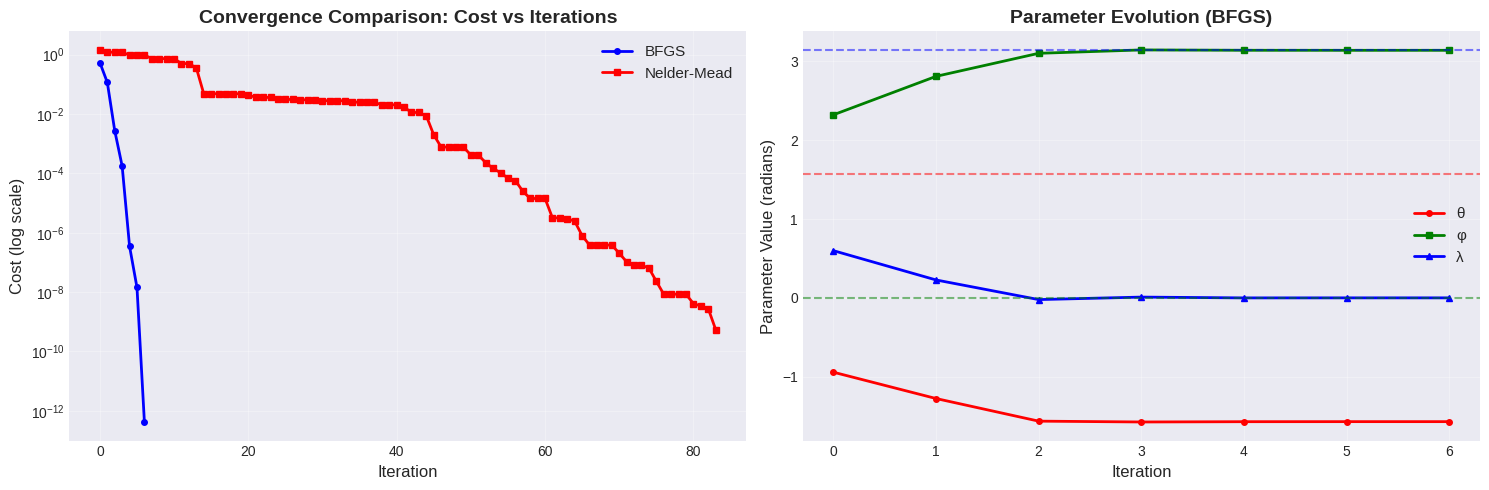

Convergence plots created!


In [21]:
# Create convergence plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Error over iterations
ax1.semilogy(history_bfgs['iter'], history_bfgs['cost'], 'b-',
             linewidth=2, label='BFGS', marker='o', markersize=4)
ax1.semilogy(history_nm['iter'], history_nm['cost'], 'r-',
             linewidth=2, label='Nelder-Mead', marker='s', markersize=4)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Cost (log scale)', fontsize=12)
ax1.set_title('Convergence Comparison: Cost vs Iterations', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Parameter evolution for BFGS
params_array = np.array(history_bfgs['params'])
ax2.plot(history_bfgs['iter'], params_array[:, 0], 'r-', linewidth=2,
         label='θ', marker='o', markersize=4)
ax2.plot(history_bfgs['iter'], params_array[:, 1], 'g-', linewidth=2,
         label='φ', marker='s', markersize=4)
ax2.plot(history_bfgs['iter'], params_array[:, 2], 'b-', linewidth=2,
         label='λ', marker='^', markersize=4)
ax2.axhline(y=theta_analytical, color='r', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.axhline(y=phi_analytical, color='g', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.axhline(y=lambda_analytical, color='b', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Parameter Value (radians)', fontsize=12)
ax2.set_title('Parameter Evolution (BFGS)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Convergence plots created!")

## Step 8: Visualize Cost Function Landscape

Plot 2D slices of the cost function to visualize the optimization landscape.

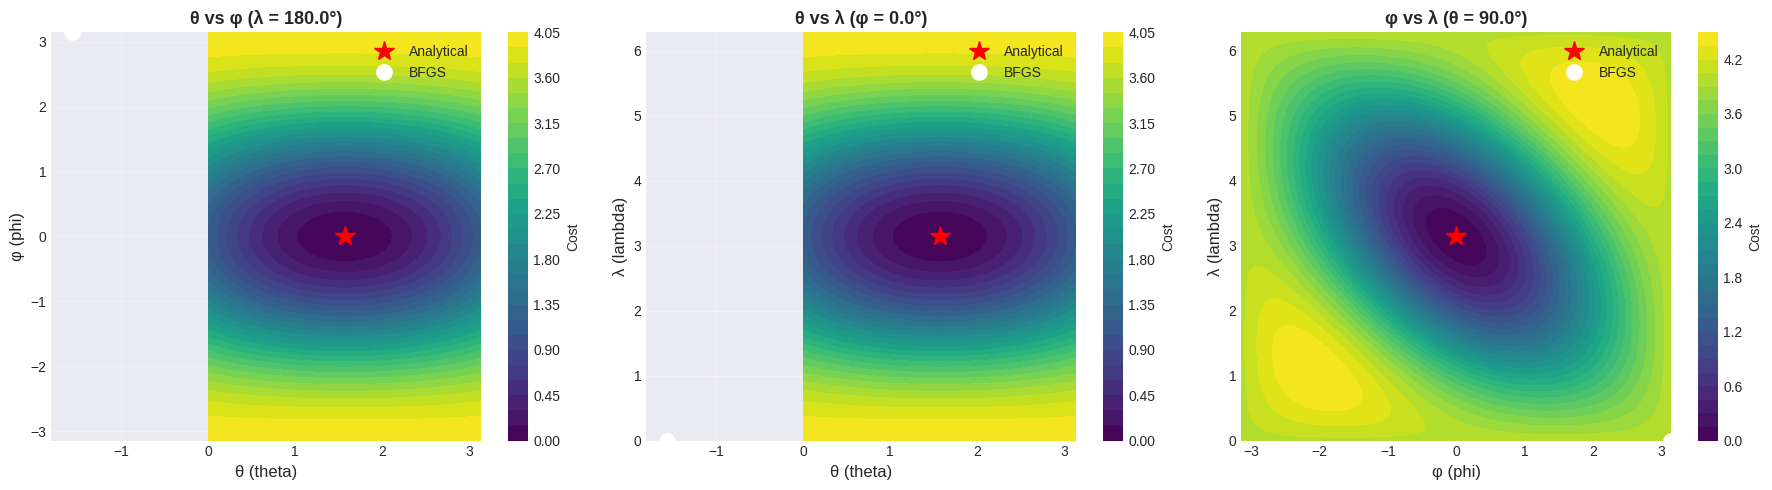

✓ Cost landscape visualization created!


In [22]:
# Create 2D contour plots for parameter pairs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n_points = 100

# Plot 1: theta vs phi (lambda fixed)
theta_range = np.linspace(0, np.pi, n_points)
phi_range = np.linspace(-np.pi, np.pi, n_points)
Theta, Phi = np.meshgrid(theta_range, phi_range)
Cost1 = np.zeros_like(Theta)
for i in range(n_points):
    for j in range(n_points):
        Cost1[j, i] = cost_function([Theta[j, i], Phi[j, i], lambda_analytical])

contour1 = axes[0].contourf(Theta, Phi, Cost1, levels=30, cmap='viridis')
axes[0].plot(theta_analytical, phi_analytical, 'r*', markersize=15, label='Analytical', zorder=5)
axes[0].plot(theta_bfgs, phi_bfgs, 'wo', markersize=10, markeredgewidth=2, label='BFGS', zorder=5)
axes[0].set_xlabel('θ (theta)', fontsize=12)
axes[0].set_ylabel('φ (phi)', fontsize=12)
axes[0].set_title(f'θ vs φ (λ = {np.degrees(lambda_analytical):.1f}°)', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
plt.colorbar(contour1, ax=axes[0], label='Cost')

# Plot 2: theta vs lambda (phi fixed)
lambda_range = np.linspace(0, 2*np.pi, n_points)
Theta, Lambda = np.meshgrid(theta_range, lambda_range)
Cost2 = np.zeros_like(Theta)
for i in range(n_points):
    for j in range(n_points):
        Cost2[j, i] = cost_function([Theta[j, i], phi_analytical, Lambda[j, i]])

contour2 = axes[1].contourf(Theta, Lambda, Cost2, levels=30, cmap='viridis')
axes[1].plot(theta_analytical, lambda_analytical, 'r*', markersize=15, label='Analytical', zorder=5)
axes[1].plot(theta_bfgs, lambda_bfgs, 'wo', markersize=10, markeredgewidth=2, label='BFGS', zorder=5)
axes[1].set_xlabel('θ (theta)', fontsize=12)
axes[1].set_ylabel('λ (lambda)', fontsize=12)
axes[1].set_title(f'θ vs λ (φ = {np.degrees(phi_analytical):.1f}°)', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.colorbar(contour2, ax=axes[1], label='Cost')

# Plot 3: phi vs lambda (theta fixed)
Phi, Lambda = np.meshgrid(phi_range, lambda_range)
Cost3 = np.zeros_like(Phi)
for i in range(n_points):
    for j in range(n_points):
        Cost3[j, i] = cost_function([theta_analytical, Phi[j, i], Lambda[j, i]])

contour3 = axes[2].contourf(Phi, Lambda, Cost3, levels=30, cmap='viridis')
axes[2].plot(phi_analytical, lambda_analytical, 'r*', markersize=15, label='Analytical', zorder=5)
axes[2].plot(phi_bfgs, lambda_bfgs, 'wo', markersize=10, markeredgewidth=2, label='BFGS', zorder=5)
axes[2].set_xlabel('φ (phi)', fontsize=12)
axes[2].set_ylabel('λ (lambda)', fontsize=12)
axes[2].set_title(f'φ vs λ (θ = {np.degrees(theta_analytical):.1f}°)', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
plt.colorbar(contour3, ax=axes[2], label='Cost')

plt.tight_layout()
plt.show()

print("Cost landscape visualization created!")

## Step 9: 1D Cross-Sections Through Optimal Solution

Show how cost varies when changing one parameter at a time.

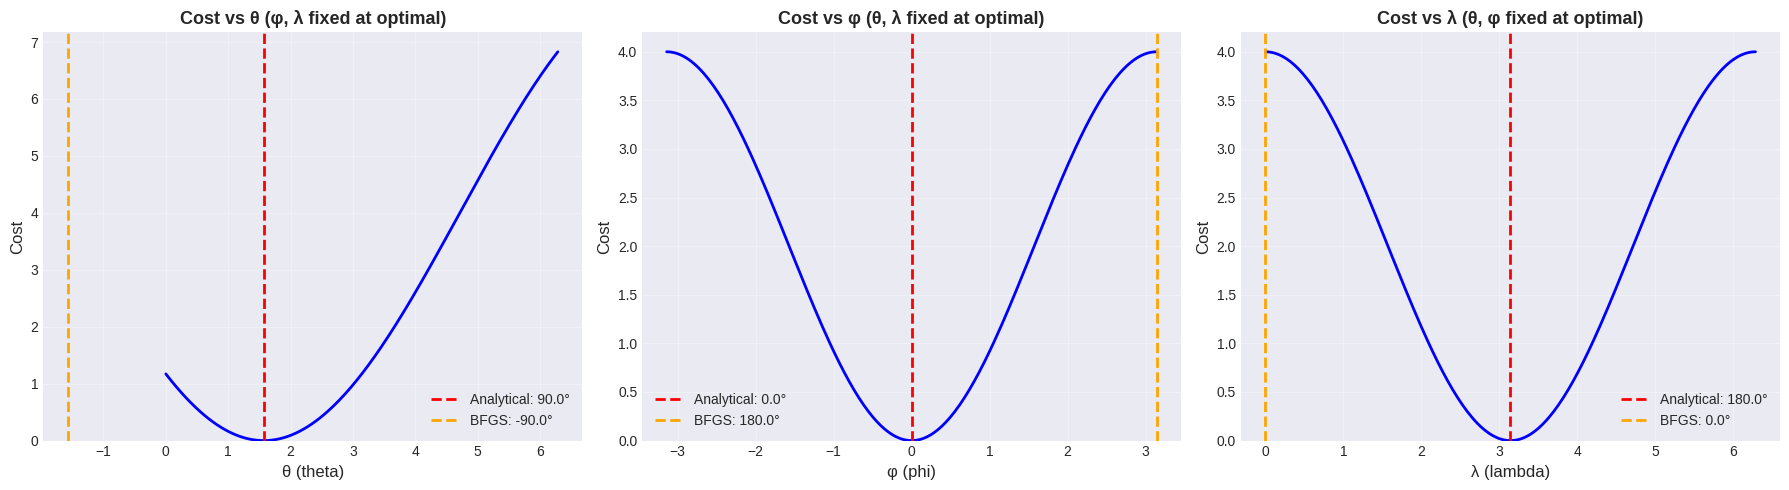

1D cross-section plots created!


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n_points = 200

# Plot 1: Varying theta
theta_vals = np.linspace(0, 2*np.pi, n_points)
cost_theta = [cost_function([t, phi_analytical, lambda_analytical]) for t in theta_vals]
axes[0].plot(theta_vals, cost_theta, 'b-', linewidth=2)
axes[0].axvline(theta_analytical, color='r', linestyle='--', linewidth=2,
                label=f'Analytical: {np.degrees(theta_analytical):.1f}°')
axes[0].axvline(theta_bfgs, color='orange', linestyle='--', linewidth=2,
                label=f'BFGS: {np.degrees(theta_bfgs):.1f}°')
axes[0].set_xlabel('θ (theta)', fontsize=12)
axes[0].set_ylabel('Cost', fontsize=12)
axes[0].set_title('Cost vs θ (φ, λ fixed at optimal)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Plot 2: Varying phi
phi_vals = np.linspace(-np.pi, np.pi, n_points)
cost_phi = [cost_function([theta_analytical, p, lambda_analytical]) for p in phi_vals]
axes[1].plot(phi_vals, cost_phi, 'b-', linewidth=2)
axes[1].axvline(phi_analytical, color='r', linestyle='--', linewidth=2,
                label=f'Analytical: {np.degrees(phi_analytical):.1f}°')
axes[1].axvline(phi_bfgs, color='orange', linestyle='--', linewidth=2,
                label=f'BFGS: {np.degrees(phi_bfgs):.1f}°')
axes[1].set_xlabel('φ (phi)', fontsize=12)
axes[1].set_ylabel('Cost', fontsize=12)
axes[1].set_title('Cost vs φ (θ, λ fixed at optimal)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)

# Plot 3: Varying lambda
lambda_vals = np.linspace(0, 2*np.pi, n_points)
cost_lambda = [cost_function([theta_analytical, phi_analytical, l]) for l in lambda_vals]
axes[2].plot(lambda_vals, cost_lambda, 'b-', linewidth=2)
axes[2].axvline(lambda_analytical, color='r', linestyle='--', linewidth=2,
                label=f'Analytical: {np.degrees(lambda_analytical):.1f}°')
axes[2].axvline(lambda_bfgs, color='orange', linestyle='--', linewidth=2,
                label=f'BFGS: {np.degrees(lambda_bfgs):.1f}°')
axes[2].set_xlabel('λ (lambda)', fontsize=12)
axes[2].set_ylabel('Cost', fontsize=12)
axes[2].set_title('Cost vs λ (θ, φ fixed at optimal)', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("1D cross-section plots created!")

## Step 10: Summary Comparison Table

In [27]:
# Create comparison table
comparison_data = {
    'Method': ['Analytical', 'BFGS', 'Nelder-Mead'],
    'θ (deg)': [
        f"{np.degrees(theta_analytical):.4f}°",
        f"{np.degrees(theta_bfgs):.4f}°",
        f"{np.degrees(theta_nm):.4f}°"
    ],
    'φ (deg)': [
        f"{np.degrees(phi_analytical):.4f}°",
        f"{np.degrees(phi_bfgs):.4f}°",
        f"{np.degrees(phi_nm):.4f}°"
    ],
    'λ (deg)': [
        f"{np.degrees(lambda_analytical):.4f}°",
        f"{np.degrees(lambda_bfgs):.4f}°",
        f"{np.degrees(lambda_nm):.4f}°"
    ],
    'Max Error': [
        f"{error_analytical:.2e}",
        f"{error_bfgs:.2e}",
        f"{error_nm:.2e}"
    ],
    'Iterations': [
        '1 (Direct)',
        f"{len(history_bfgs['iter'])}",
        f"{len(history_nm['iter'])}"
    ],
    'Speed': ['Fastest', 'Fast', 'Slower']
}

df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("FINAL COMPARISON: ALL METHODS")
print("="*80)
print(f"\nTarget: U(θ, φ, λ) = H (Hadamard Gate)\n")
print(df.to_string(index=False))
print("\n" + "="*80)
print("\nAll methods completed successfully!")


FINAL COMPARISON: ALL METHODS

Target: U(θ, φ, λ) = H (Hadamard Gate)

     Method   θ (deg)   φ (deg)   λ (deg) Max Error Iterations   Speed
 Analytical  90.0000°   0.0000° 180.0000°  1.41e-16 1 (Direct) Fastest
       BFGS -90.0000° 180.0000°   0.0000°  4.14e-07          7    Fast
Nelder-Mead -90.0012° 180.0012°  -0.0006°  1.66e-05         84  Slower


All methods completed successfully!


## Step 11: Verify the Solution

Let's verify that our optimized parameters actually produce the Hadamard gate.

In [29]:
# Compute U with analytical parameters
U_final = U_gate(theta_analytical, phi_analytical, lambda_analytical)

print("U(θ, φ, λ) with analytical parameters:")
print(U_final)
print("\nTarget Hadamard gate H:")
print(H)
print("\nDifference (U - H):")
print(U_final - H)
print(f"\nMaximum absolute difference: {np.max(np.abs(U_final - H)):.15e}")
print(f"Matrices are equal: {np.allclose(U_final, H)}")

print("\n" + "="*80)
print("SOLUTION VERIFICATION")
print("="*80)
print(f"U({np.degrees(theta_analytical):.1f}°, {np.degrees(phi_analytical):.1f}°, {np.degrees(lambda_analytical):.1f}°) = H")
print("The analytical solution is EXACT!")
print("="*80)

U(θ, φ, λ) with analytical parameters:
[[ 0.70710678+0.00000000e+00j  0.70710678-8.65956056e-17j]
 [ 0.70710678+0.00000000e+00j -0.70710678+8.65956056e-17j]]

Target Hadamard gate H:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]

Difference (U - H):
[[ 1.11022302e-16+0.00000000e+00j  0.00000000e+00-8.65956056e-17j]
 [ 0.00000000e+00+0.00000000e+00j -1.11022302e-16+8.65956056e-17j]]

Maximum absolute difference: 1.408003926038120e-16
Matrices are equal: True

SOLUTION VERIFICATION
U(90.0°, 0.0°, 180.0°) = H
The analytical solution is EXACT!


## Summary

We successfully created an optimization algorithm that finds the parameters θ, φ, and λ such that:

$$U(\theta, \phi, \lambda) = H$$

### The solution is:
- **θ = π/2** (90°)
- **φ = 0** (0°)
- **λ = π** (180°)

### Methods Used:
1. **Analytical Solution**: Direct calculation from matrix elements
2. **BFGS Optimization**: Quasi-Newton method
3. **Nelder-Mead**: Derivative-free simplex method

All three methods successfully found the correct parameters that transform the universal U gate into the Hadamard gate!